# 05 — Naive Bayes Interpretability
Analyse the Gaussian distributions learned per class and compare feature means between survivors and deceased patients.

In [ ]:
import sys
sys.path.insert(0, '..')

from src.data import load_data, split_data
from src.models import train_naive_bayes
from src.interpret_nb import class_statistics, plot_feature_distributions

In [ ]:
X, y = load_data('../data/heart_failure_clinical_records_dataset.csv')
X_train, X_test, y_train, y_test = split_data(X, y)

pipeline = train_naive_bayes(X_train, y_train)

FEATURE_NAMES = list(X.columns)
CLASS_NAMES = ['survived', 'deceased']

## Class Statistics
Mean and standard deviation of each feature, conditioned on the class.
These are the exact parameters stored in the model — `theta_` (means) and `var_` (variances).
A large difference in means between classes signals a feature the model is relying on heavily.

In [3]:
stats = class_statistics(pipeline, FEATURE_NAMES)
stats['mean_diff'] = (stats['mean_deceased'] - stats['mean_survived']).abs().round(3)
stats = stats.sort_values('mean_diff', ascending=False).reset_index(drop=True)
stats.round(3)

,feature,mean_survived,std_survived,mean_deceased,std_deceased,mean_diff
0,ejection_fraction,-0.213,0.589,0.447,1.442,0.660
1,creatinine_phosphokinase,0.193,0.908,-0.405,1.062,0.598
2,age,-0.136,0.911,0.286,1.112,0.421
3,high_blood_pressure,0.111,0.916,-0.234,1.121,0.345
4,anaemia,-0.063,0.707,0.132,1.423,0.194
5,serum_sodium,0.340,0.474,0.442,0.497,0.102
6,diabetes,0.031,0.991,-0.064,1.016,0.095
7,platelets,0.420,0.494,0.506,0.500,0.087
8,serum_creatinine,0.432,0.495,0.481,0.500,0.048
9,smoking,0.309,0.462,0.338,0.473,0.029


## Gaussian Distributions per Feature
Each subplot shows the learned Gaussian for survivors (blue) and deceased (red).
- **Well-separated curves** → feature is informative to the model
- **Overlapping curves** → feature adds little discriminative power
- Dashed vertical lines mark the class means

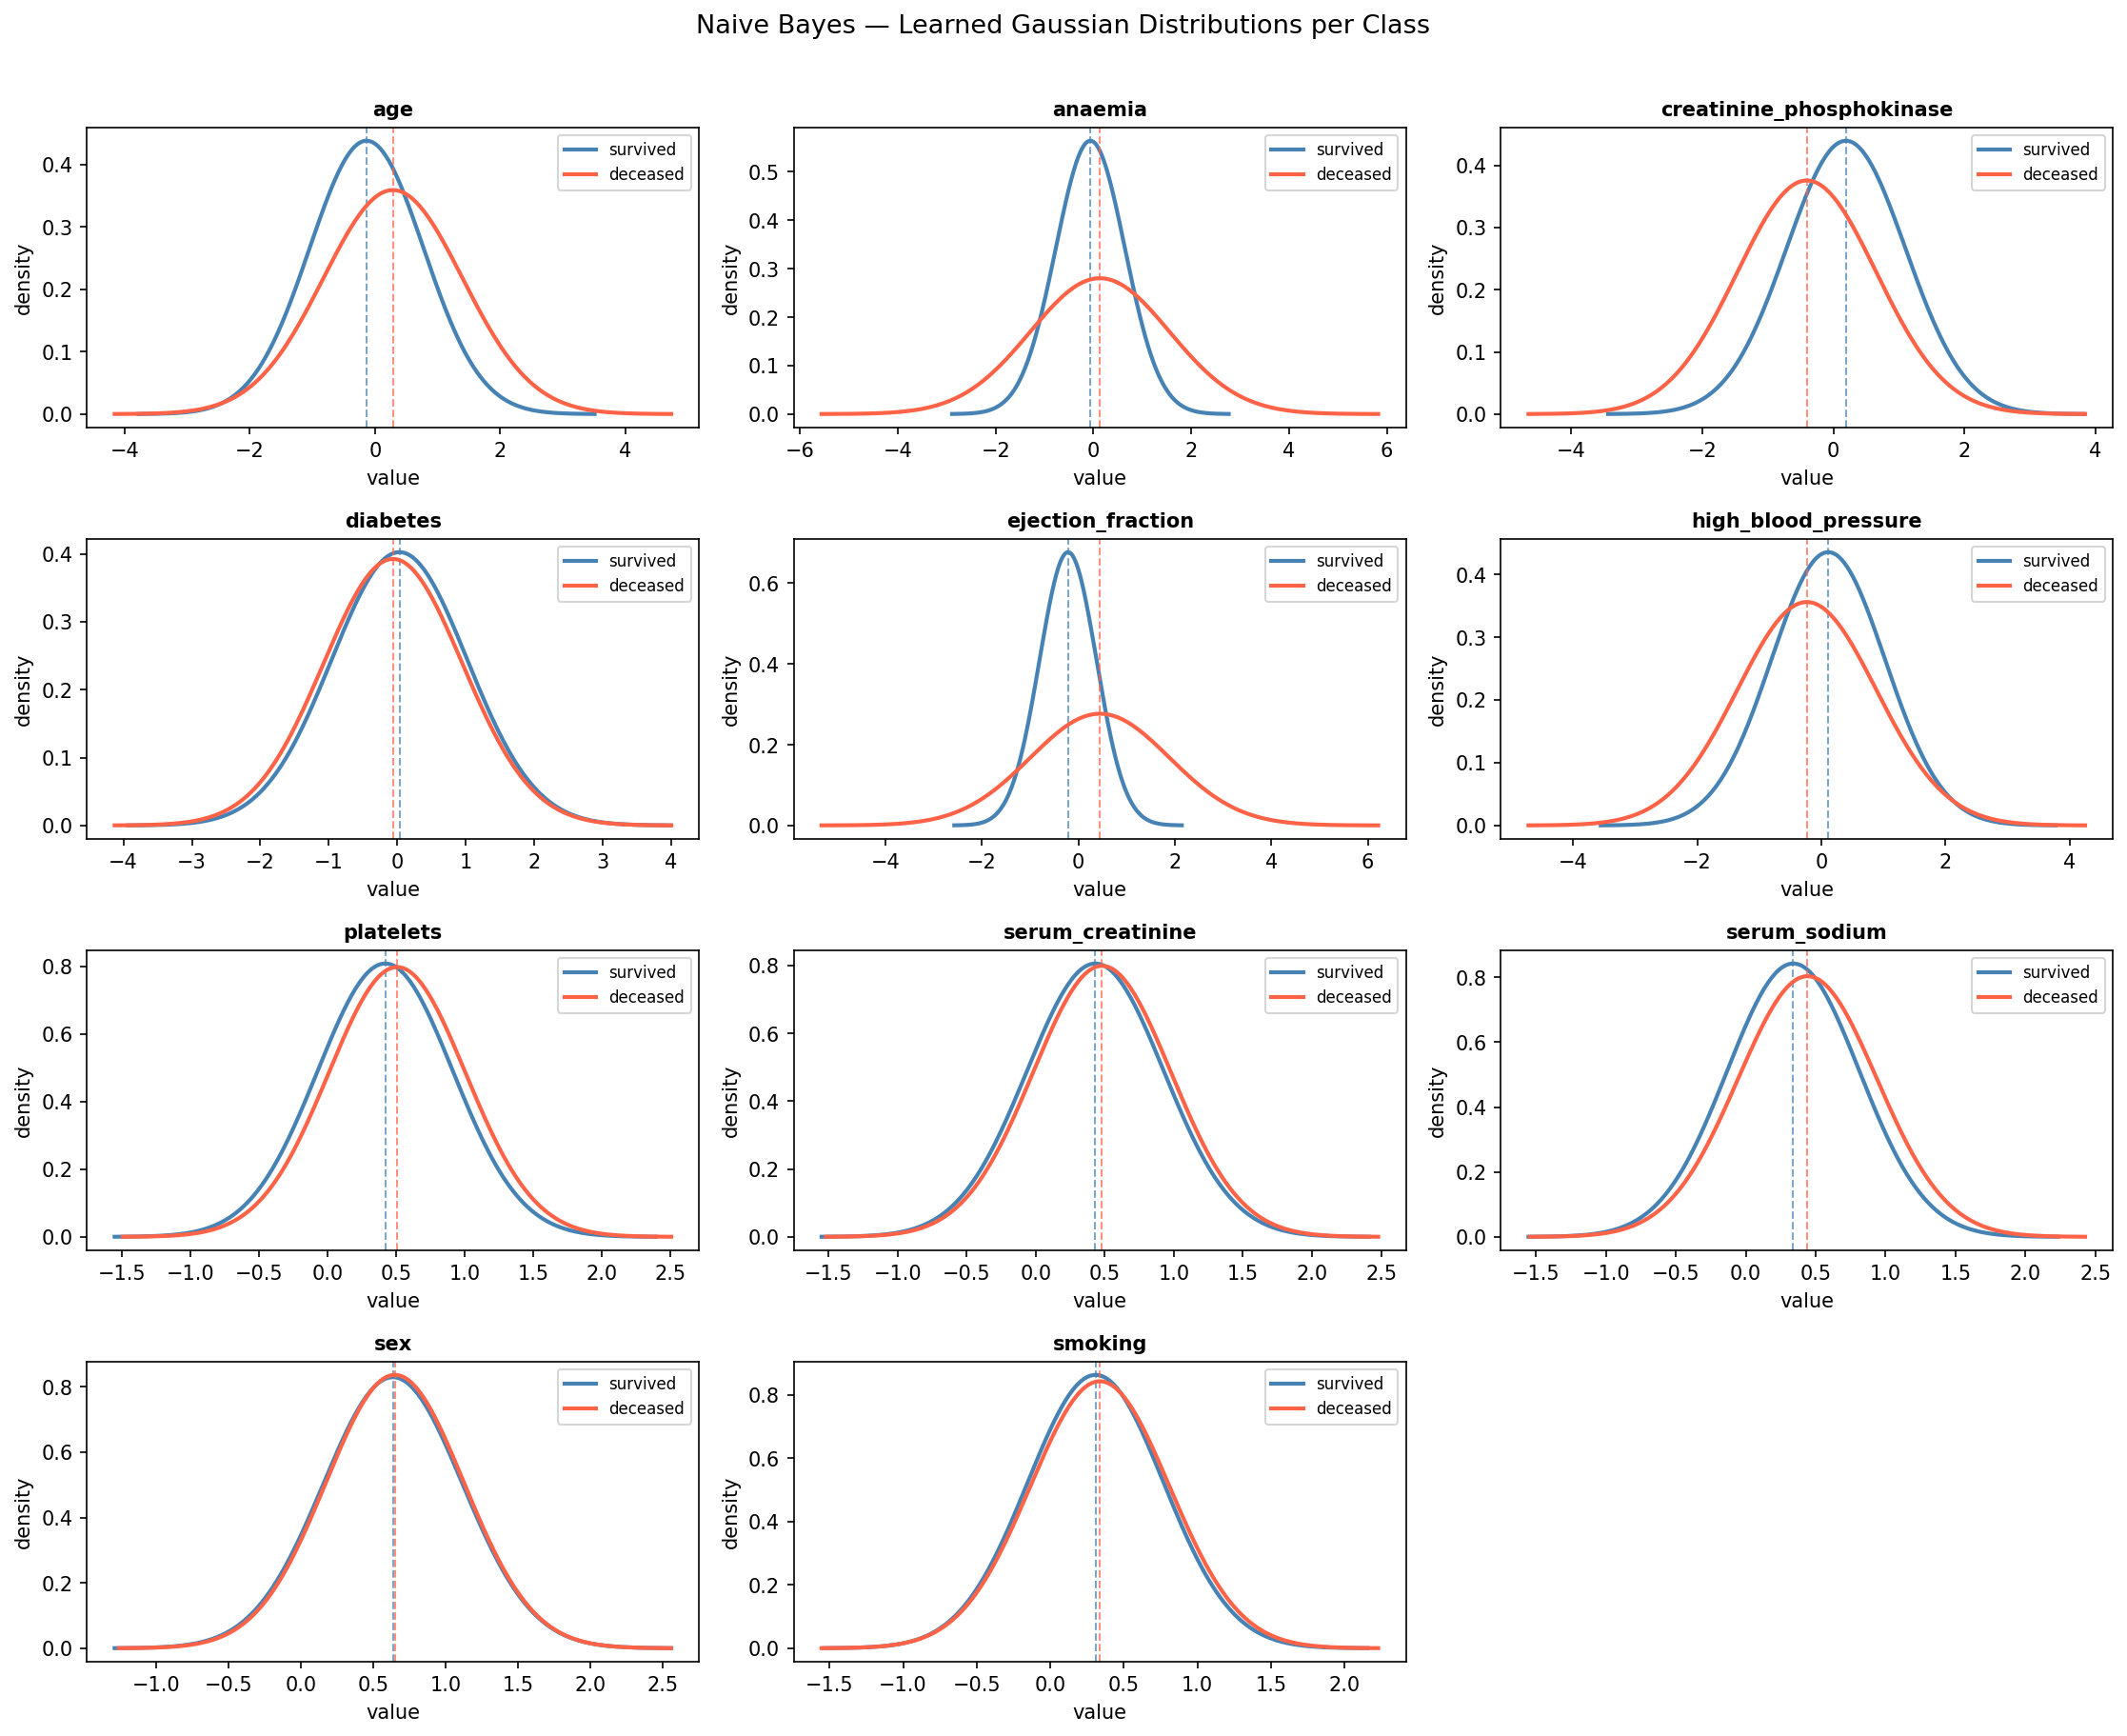

In [4]:
plot_feature_distributions(
    pipeline, FEATURE_NAMES, CLASS_NAMES,
    path='../outputs/nb_distributions.png'
)

from IPython.display import Image
Image('../outputs/nb_distributions.png')

## Observations

- **`serum_creatinine`** — deceased patients have a higher mean, consistent with kidney dysfunction being a strong mortality predictor. Curves are meaningfully separated.
- **`ejection_fraction`** — survivors have a higher mean (better heart pumping capacity). Separation is moderate but clinically meaningful.
- **`serum_sodium`** — lower sodium in deceased patients (hyponatremia is associated with worse outcomes). Moderate separation.
- **`age`** — deceased patients are slightly older on average, but the distributions overlap substantially — age alone is a weak discriminator here.
- **Binary features** (`anaemia`, `diabetes`, `high_blood_pressure`, `sex`, `smoking`) — modelled as Gaussians over 0/1 values. This is a known limitation of GaussianNB: binary features violate the Gaussian assumption. Their distributions will appear as two narrow spikes rather than smooth curves.

### Comparison with Decision Tree
Both models agree that `serum_creatinine` and `ejection_fraction` are the dominant features.
Naive Bayes additionally uses all features simultaneously (probabilistic combination), while the Decision Tree only uses the 3–4 features that appear in its splits.